In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\Electronics_recommendation_system\data\All Electronics.csv")

In [3]:
df.head()

,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price
0,"Redmi 10 Power (Power Black, 8GB RAM, 128GB St...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/81eM15lVcJ...,https://www.amazon.in/Redmi-Power-Black-128GB-...,4.0,965,"₹10,999","₹18,999"
1,"OnePlus Nord CE 2 Lite 5G (Blue Tide, 6GB RAM,...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/71AvQd3Vzq...,https://www.amazon.in/OnePlus-Nord-Lite-128GB-...,4.3,"113,956","₹18,999","₹19,999"
2,OnePlus Bullets Z2 Bluetooth Wireless in Ear E...,"tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/51UhwaQXCp...,https://www.amazon.in/Oneplus-Bluetooth-Wirele...,4.2,"90,304","₹1,999","₹2,299"
3,"Samsung Galaxy M33 5G (Mystique Green, 6GB, 12...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/81I3w4J6yj...,https://www.amazon.in/Samsung-Mystique-Storage...,4.1,"24,863","₹15,999","₹24,999"
4,"OnePlus Nord CE 2 Lite 5G (Black Dusk, 6GB RAM...","tv, audio & cameras",All Electronics,https://m.media-amazon.com/images/I/71V--WZVUI...,https://www.amazon.in/OnePlus-Nord-Black-128GB...,4.3,"113,956","₹18,999","₹19,999"


In [4]:
df.dtypes

name              object
main_category     object
sub_category      object
image             object
link              object
ratings           object
no_of_ratings     object
discount_price    object
actual_price      object
dtype: object

In [5]:
df.isna().sum()

name                0
main_category       0
sub_category        0
image               0
link                0
ratings            95
no_of_ratings      95
discount_price    484
actual_price       70
dtype: int64

In [6]:
df["ratings"].value_counts()

ratings
4.3    1310
4.2    1213
4.1    1167
4.0     980
4.4     875
3.9     808
3.8     617
4.5     584
3.7     404
3.6     313
4.6     251
3.5     203
3.4     162
3.3     102
5.0      97
4.7      95
3.2      61
3.1      45
3.0      45
4.8      39
2.9      26
Get      24
2.8      18
2.6       9
4.9       9
1.0       8
2.5       7
2.7       7
2.4       6
2.2       4
2.3       3
2.1       3
1.7       2
1.5       2
2.0       2
1.9       1
1.3       1
1.8       1
1.4       1
Name: count, dtype: int64

In [7]:
df["discount_price"]=df["discount_price"].astype("str").str.replace("₹","").str.replace(",","").str.strip()
df["discount_price"]=pd.to_numeric(df["discount_price"],errors="coerce")
df["ratings"]=pd.to_numeric(df["ratings"], errors="coerce")
df["no_of_ratings"]=df["no_of_ratings"].astype("str").str.replace(",","").str.strip()
df["no_of_ratings"]=pd.to_numeric(df["no_of_ratings"],errors="coerce")
df["actual_price"]=df["actual_price"].astype("str").str.replace("₹"," ").str.replace(",","").str.strip()
df["actual_price"]=pd.to_numeric(df["actual_price"],errors="coerce")

In [8]:
df.dtypes

name               object
main_category      object
sub_category       object
image              object
link               object
ratings           float64
no_of_ratings     float64
discount_price    float64
actual_price      float64
dtype: object

In [9]:
df.isna().sum()

name                0
main_category       0
sub_category        0
image               0
link                0
ratings           119
no_of_ratings     119
discount_price    484
actual_price       70
dtype: int64

In [10]:
df.dropna(subset=['ratings', 'no_of_ratings'], inplace=True)

In [11]:
df["discount_price"]=df["discount_price"].fillna(df["actual_price"])

In [12]:
df.isna().sum()

name               0
main_category      0
sub_category       0
image              0
link               0
ratings            0
no_of_ratings      0
discount_price    70
actual_price      70
dtype: int64

In [13]:
df['actual_price'] = df['actual_price'].fillna(df['actual_price'].median())
df['discount_price'] = df['discount_price'].fillna(df['discount_price'].median())

In [14]:
df.isna().sum()

name              0
main_category     0
sub_category      0
image             0
link              0
ratings           0
no_of_ratings     0
discount_price    0
actual_price      0
dtype: int64

In [16]:
df.drop("sub_category",axis=1,inplace=True)

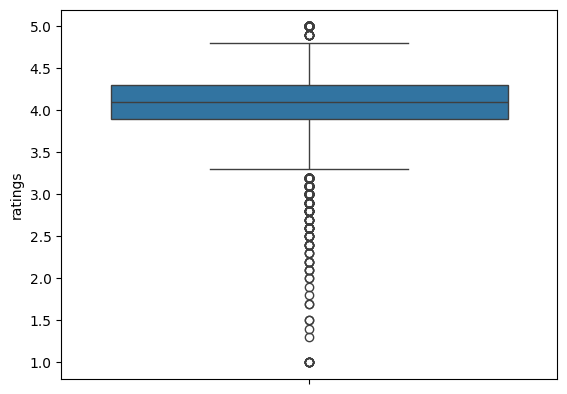

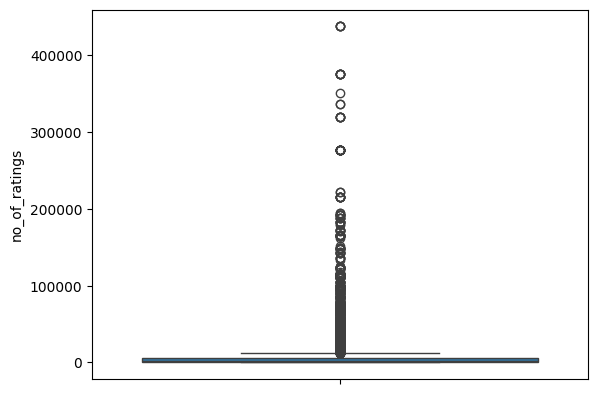

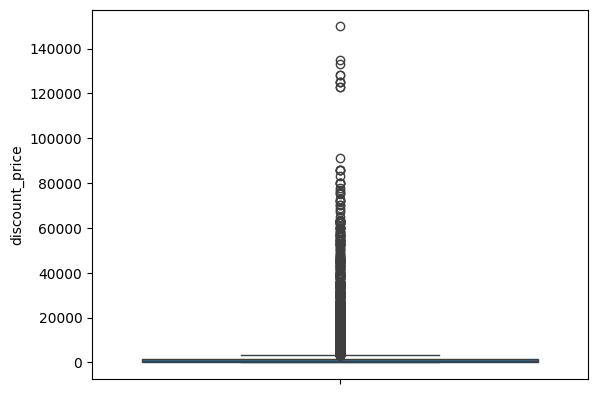

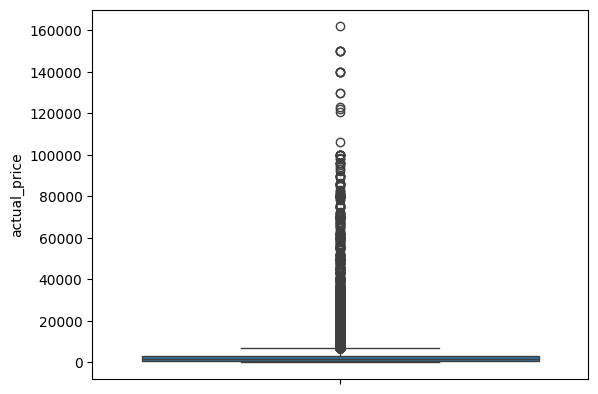

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
num_cols=df.select_dtypes(exclude="object").columns
for col in num_cols:
    sns.boxplot(df[col])
    plt.show()